# GANisme — 07. Optimisation des hyperparamètres avec Optuna (portraits 64×80)

**Pourquoi cette étude.** Les trois premiers modèles ont montré que le problème central est l'**équilibre entre
générateur et discriminateur** : trop fort (modèle n°1), instable (n°2), trop faible (n°3). Le modèle n°3 a surtout
montré qu'une technique (la normalisation spectrale) échoue si ses hyperparamètres ne lui correspondent pas. Plutôt que
de tester les combinaisons à la main, on confie la recherche à **Optuna**.

**Méthode** (détaillée dans `src/optuna_search.py`) :

| Choix | Valeur | Raison |
|---|---|---|
| Algorithme | TPE multivarié (8 premiers essais aléatoires ou imposés) | efficace quand chaque essai coûte cher |
| Budget par essai | 300 époques, évaluation allégée toutes les 25 | ~10 à 25 min par essai |
| Objectif | **moyenne du FID des 3 dernières évaluations** | pénalise les effondrements de fin d'entraînement |
| Élagage | quart le moins bon à la même époque, jamais avant l'époque 125 | ne pas éliminer les réglages lents à converger |
| Graine | identique pour tous les essais | les écarts viennent des hyperparamètres |
| Premiers essais imposés | réglages des modèles n°2 et n°3, SNGAN + TTUR, SNGAN « à la Miyato » | points de repère |

**Espace de recherche** : perte (BCE / hinge), normalisation spectrale (oui / non), taux d'apprentissage de G et de D
(échelle log), β₁ ∈ {0 ; 0,5}, β₂ ∈ {0,9 ; 0,999}, mises à jour de D par itération (1 à 3), politique DiffAugment
(4 variantes), taille de batch (64 / 128).

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import optuna
from PIL import Image
from matplotlib_inline.backend_inline import set_matplotlib_formats

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "reports" / "figures"
TRIALS_DIR = ROOT / "runs" / "optuna" / "portrait_64"
set_matplotlib_formats("jpeg", pil_kwargs={"quality": 88})

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"optuna_{name}.png")


study = optuna.load_study(study_name="portrait_64", storage=f"sqlite:///{(ROOT / 'reports' / 'optuna' / 'portrait_64.db').as_posix()}")
rows = []
for t in study.trials:
    rows.append({"essai": t.number, "état": t.state.name, "objectif": t.value, **t.params,
                 "meilleur_FID": t.user_attrs.get("best_fid"), "tendance": t.user_attrs.get("fid_trend"),
                 "précision": t.user_attrs.get("last_precision"), "rappel": t.user_attrs.get("last_recall"),
                 "minutes": t.user_attrs.get("minutes")})
T = pd.DataFrame(rows)
T["ratio_lr"] = T["lr_d"] / T["lr_g"]
T["imposé"] = T["essai"] < 4
print(f"{len(T)} essais : {T['état'].value_counts().to_dict()} — {T['minutes'].sum() / 60:.1f} h de calcul")

30 essais : {'COMPLETE': 24, 'PRUNED': 6} — 7.5 h de calcul


## 1. Historique de l'étude

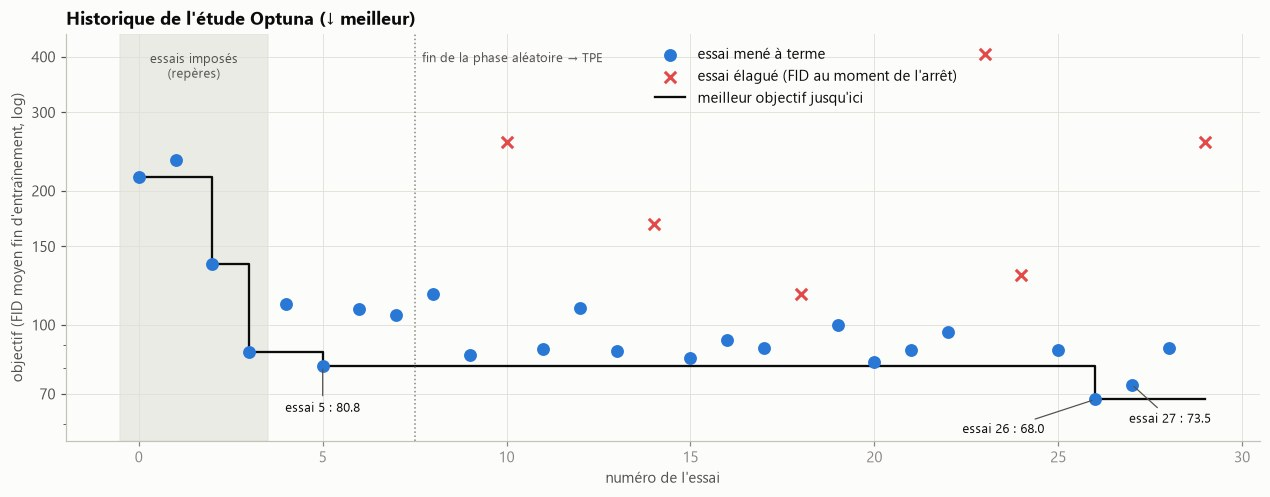

In [2]:
fig, ax = plt.subplots(figsize=(14, 4.8))
comp, pr = T[T["état"] == "COMPLETE"], T[T["état"] == "PRUNED"]
ax.scatter(comp["essai"], comp["objectif"], s=55, color=MAIN, zorder=3, label="essai mené à terme")
ax.scatter(pr["essai"], pr["objectif"], s=55, marker="x", color=CAT[7], zorder=3, label="essai élagué (FID au moment de l'arrêt)")
best_so_far = comp.set_index("essai")["objectif"].reindex(T["essai"]).cummin().ffill()
ax.step(T["essai"], best_so_far, where="post", color=INK, lw=1.5, label="meilleur objectif jusqu'ici")
ax.axvspan(-0.5, 3.5, color=GRID, alpha=0.6, zorder=0)
ax.text(1.5, ax.get_ylim()[1] * 0.97, "essais imposés\n(repères)", ha="center", va="top", fontsize=8.5, color=INK2)
ax.axvline(7.5, color=MUTED, ls=":", lw=1)
ax.text(7.7, ax.get_ylim()[1] * 0.97, "fin de la phase aléatoire → TPE", va="top", fontsize=8.5, color=INK2)
for (_, r), (dx, dy) in zip(comp.nsmallest(3, "objectif").iterrows(), ((-60, -22), (25, -25), (0, -30))):
    ax.annotate(f"essai {r['essai']} : {r['objectif']:.1f}", (r["essai"], r["objectif"]), xytext=(dx, dy),
                textcoords="offset points", ha="center", fontsize=8.5, color=INK,
                arrowprops={"arrowstyle": "-", "color": INK2, "lw": 0.8})
ax.set_yscale("log"); ax.set_yticks([70, 100, 150, 200, 300, 400]); ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
ax.yaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_xlabel("numéro de l'essai"); ax.set_ylabel("objectif (FID moyen fin d'entraînement, log)")
ax.set_ylim(55, 450)
ax.set_title("Historique de l'étude Optuna (↓ meilleur)"); ax.legend(loc="upper center", bbox_to_anchor=(0.62, 1))
save(fig, "01_history")
plt.show()

In [3]:
cols = ["essai", "état", "objectif", "meilleur_FID", "tendance", "précision", "rappel", "loss", "spectral_norm",
        "lr_g", "lr_d", "ratio_lr", "beta1", "beta2", "n_dis", "diffaug", "batch_size", "minutes"]
T.sort_values("objectif")[cols].head(12).round({"objectif": 1, "meilleur_FID": 1, "tendance": 1, "précision": 2,
                                                  "rappel": 2, "lr_g": 6, "lr_d": 6, "ratio_lr": 1})

,essai,état,objectif,meilleur_FID,tendance,précision,rappel,loss,spectral_norm,lr_g,lr_d,ratio_lr,beta1,beta2,n_dis,diffaug,batch_size,minutes
26,26,COMPLETE,68.0,66.5,0.3,0.60,0.18,bce,True,0.000304,0.000498,1.6,0.0,0.999,2,"color,translation",64,17.0
27,27,COMPLETE,73.5,69.0,-13.0,0.56,0.19,bce,False,0.000093,0.000907,9.8,0.0,0.999,2,"color,translation",64,15.6
5,5,COMPLETE,80.8,72.6,-3.2,0.56,0.21,hinge,True,0.000116,0.000196,1.7,0.0,0.999,2,"color,translation",64,17.0
20,20,COMPLETE,82.4,73.2,-11.9,0.58,0.19,bce,True,0.000187,0.000833,4.5,0.0,0.999,2,"color,translation",64,17.0
15,15,COMPLETE,84.2,79.4,-8.1,0.52,0.18,hinge,True,0.000493,0.000382,0.8,0.0,0.999,2,"color,translation",64,17.0
9,9,COMPLETE,85.5,83.5,-1.4,0.57,0.17,hinge,True,0.000444,0.000808,1.8,0.0,0.999,2,"color,translation",64,17.0
3,3,COMPLETE,86.8,77.9,-5.4,0.57,0.14,hinge,True,0.000200,0.000200,1.0,0.0,0.900,3,"color,translation,cutout",64,23.3
13,13,COMPLETE,87.4,84.1,-2.1,0.60,0.16,hinge,True,0.000148,0.000482,3.2,0.0,0.999,2,"color,translation,cutout",64,17.9
21,21,COMPLETE,87.9,83.5,-2.9,0.59,0.13,bce,True,0.000149,0.000563,3.8,0.0,0.999,2,"color,translation",64,17.2
25,25,COMPLETE,88.0,86.4,-3.8,0.52,0.18,hinge,True,0.000202,0.000345,1.7,0.0,0.900,2,"color,translation",64,17.2


**Observations**

- **30 essais, 7,5 h de calcul** : 24 menés à terme, 6 élagués (tous en 7 à 14 minutes, soit environ 1 h 30 économisée).
- **Les essais imposés valident immédiatement le diagnostic du notebook 06.** Même architecture (SNGAN + DiffAugment),
  trois réglages : hyperparamètres du DCGAN → 234,6 (essai 1) ; TTUR, D 4× plus rapide que G → 136,9 (essai 2) ;
  3 mises à jour de D + batch 64 → 86,8 (essai 3). La normalisation spectrale n'était pas en cause : il fallait
  **donner plus d'entraînement au discriminateur**.
- **TPE converge vite** : après la phase aléatoire, presque tous les essais tombent entre 80 et 110, contre 105 à 235
  pendant l'exploration. Le meilleur essai (n°26, **68,0**) arrive tard, dans une zone déjà bien explorée.
- **Le meilleur réglage** : perte BCE, normalisation spectrale, lr_G = 3·10⁻⁴, lr_D = 5·10⁻⁴, Adam(0 ; 0,999),
  2 mises à jour de D par itération, DiffAugment couleur + translation (sans cutout), batch 64.
- Les 12 meilleurs essais partagent **tous** : batch 64, β₁ = 0 et (sauf un) 2 mises à jour de D.

## 2. Quels hyperparamètres comptent ?

**fANOVA** (Hutter et al., 2014) ajuste une forêt aléatoire qui prédit l'objectif à partir des hyperparamètres, puis
décompose la variance de cette prédiction : la part de variance expliquée par chaque paramètre est son
**importance**. Calculée sur les essais menés à terme, moyennée sur 5 graines de la forêt.

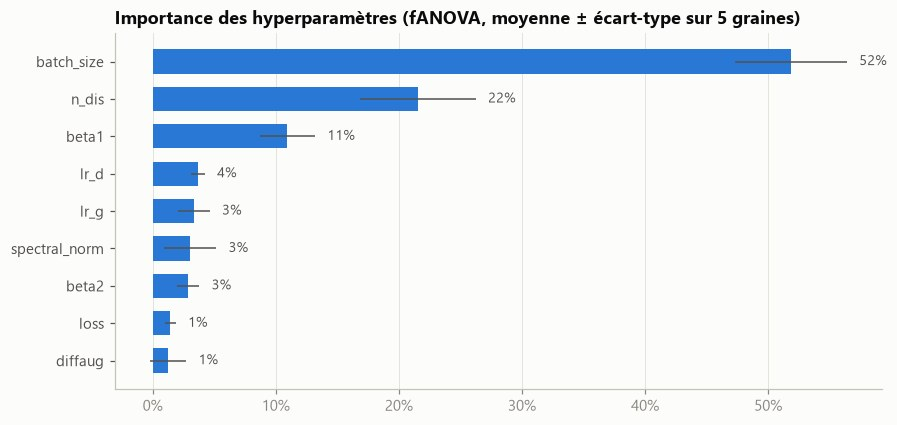

In [4]:
from optuna.importance import FanovaImportanceEvaluator

imps = pd.DataFrame([optuna.importance.get_param_importances(study, evaluator=FanovaImportanceEvaluator(seed=s))
                     for s in range(5)])
imp = imps.mean().sort_values()
err = imps.std()[imp.index]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(imp.index, imp.values, xerr=err.values, color=MAIN, height=0.65, error_kw={"ecolor": INK2, "lw": 1})
for i, v in enumerate(imp.values):
    ax.text(v + err.values[i] + 0.01, i, f"{v:.0%}", va="center", fontsize=9, color=INK2)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.grid(axis="y", visible=False)
ax.set_title("Importance des hyperparamètres (fANOVA, moyenne ± écart-type sur 5 graines)")
save(fig, "02_importances")
plt.show()

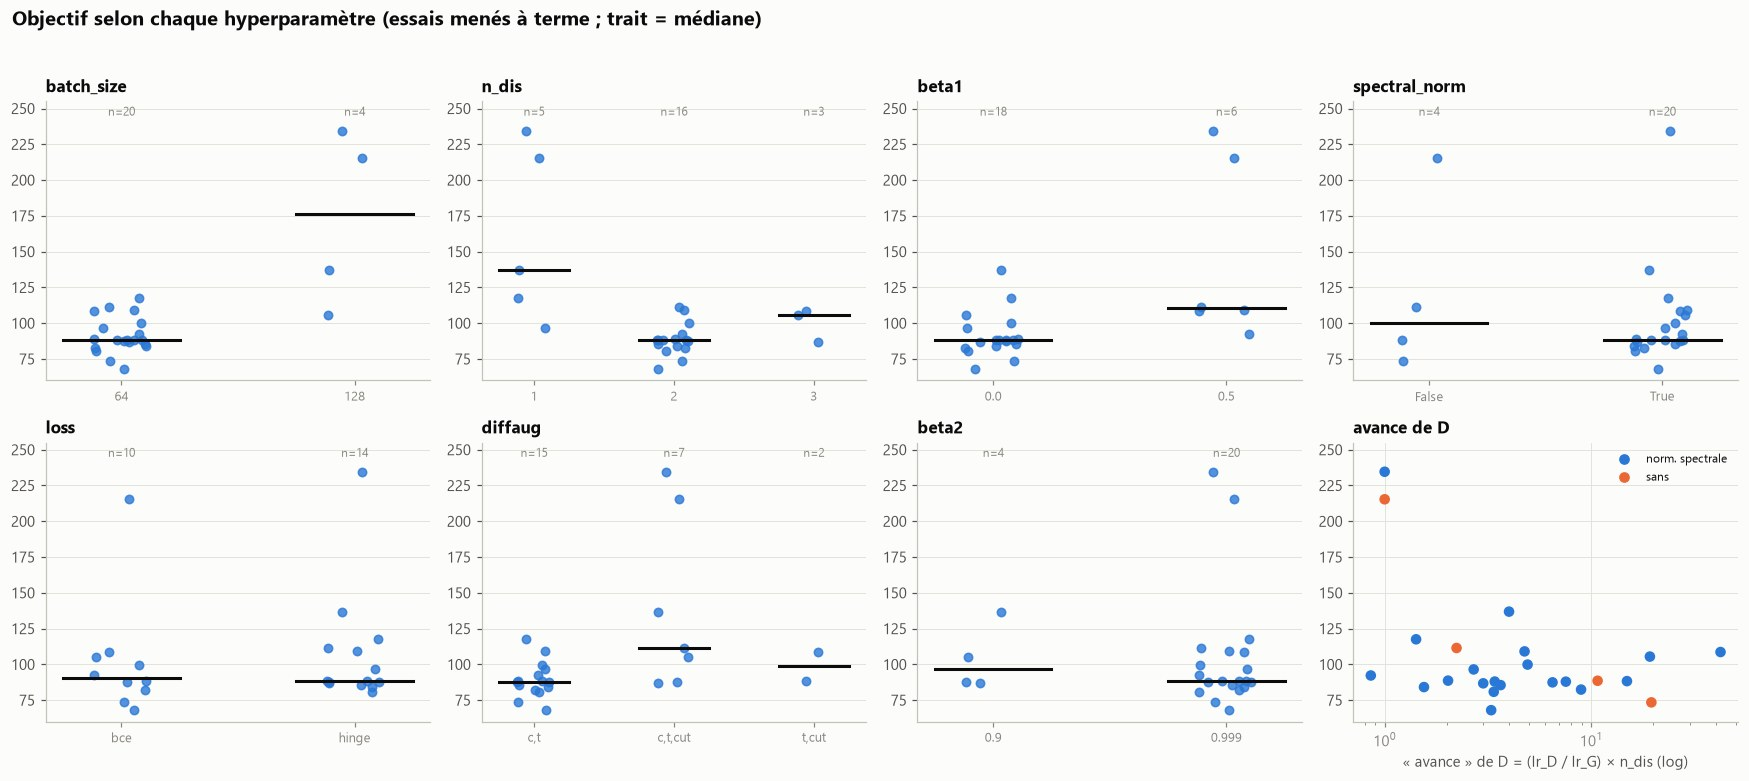

count  median    min
batch_size n_dis                      
64         1          2   107.0   96.5
           2         16    88.0   68.0
           3          2    97.7   86.8
128        1          3   215.4  136.9
           3          1   105.5  105.5

In [5]:
# Effet de chaque hyperparamètre catégoriel : objectif des essais menés à terme, par modalité
cat_params = ["batch_size", "n_dis", "beta1", "spectral_norm", "loss", "diffaug", "beta2"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7.2))
for ax, p in zip(axes.flat, cat_params):
    groups = [(str(k), g["objectif"].values) for k, g in comp.groupby(p)]
    for i, (k, v) in enumerate(groups):
        ax.scatter(np.full(len(v), i) + np.random.default_rng(0).uniform(-0.12, 0.12, len(v)), v, s=30, color=MAIN, alpha=0.8)
        ax.plot([i - 0.25, i + 0.25], [np.median(v)] * 2, color=INK, lw=2)
        ax.text(i, 245, f"n={len(v)}", ha="center", fontsize=8, color=MUTED)
    ax.set_xticks(range(len(groups)), [g[0].replace("color,translation", "c,t").replace("translation", "t").replace("cutout", "cut") or "aucune" for g in groups], fontsize=8.5)
    ax.set_ylim(60, 255); ax.set_title(p, fontsize=11); ax.grid(axis="x", visible=False)
ax = axes.flat[-1]
sc = ax.scatter(comp["ratio_lr"] * comp["n_dis"], comp["objectif"], c=comp["spectral_norm"].map({True: CAT[0], False: CAT[1]}), s=35)
ax.set_xscale("log"); ax.set_ylim(60, 255)
ax.set_xlabel("« avance » de D = (lr_D / lr_G) × n_dis (log)"); ax.set_title("avance de D", fontsize=11)
ax.scatter([], [], color=CAT[0], label="norm. spectrale"); ax.scatter([], [], color=CAT[1], label="sans")
ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Objectif selon chaque hyperparamètre (essais menés à terme ; trait = médiane)", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.96))
save(fig, "03_effects")
plt.show()

# Les deux leviers de « quantité d'entraînement » : mises à jour de G par époque et de D par époque
comp_ = comp.assign(maj_G_par_époque=(3448 // comp["batch_size"]), maj_D_par_époque=(3448 // comp["batch_size"]) * comp["n_dis"])
comp_.groupby(["batch_size", "n_dis"])["objectif"].agg(["count", "median", "min"]).round(1)

**Observations — ce qui compte vraiment**

1. **La taille de batch (52 %) et le nombre de mises à jour de D (22 %) dominent**, loin devant tout le reste. Tous
   deux règlent la **quantité d'entraînement par époque** : un batch de 64 double le nombre de mises à jour de G et de
   D, et `n_dis = 2` double encore celui de D. Avec 300 époques par essai, un batch de 128 ne fait que 7 800 mises à
   jour de G contre 15 900 pour un batch de 64. **Limite importante** : l'étude a fixé un nombre d'*époques*, pas de
   *mises à jour* ; une partie de l'avantage du batch 64 vient simplement de ce qu'il entraîne plus. Seuls 4 essais
   ont utilisé un batch de 128 — dont les deux mauvais réglages imposés —, ce qui pèse aussi sur cette importance.
2. **β₁ = 0 (11 %)** : les 12 meilleurs essais l'utilisent. Supprimer l'« inertie » d'Adam laisse les deux réseaux
   réagir plus vite l'un à l'autre, ce que recommandent les articles SNGAN et BigGAN.
3. **Les taux d'apprentissage comptent peu individuellement** (3-4 %) : ce qui compte, c'est l'**avance du
   discriminateur** (dernier graphique) — tous les bons essais ont un D qui s'entraîne au moins autant que G, via son
   taux d'apprentissage et/ou `n_dis`. Les échecs (essais 10, 14, 18, 23) avaient un G plus rapide que D.
4. **Perte BCE ou hinge (1 %), normalisation spectrale (3 %) : presque sans effet** une fois le reste bien réglé.
   Le 2ᵉ meilleur essai (n°27, 73,5) n'a **pas** de normalisation spectrale : elle devient inutile quand D est déjà
   fortement avantagé (lr_D = 10 × lr_G). Mais sans elle, l'entraînement est plus fragile : l'essai 23 (G plus rapide
   que D) a complètement échoué (FID 405).
5. **DiffAugment : la politique importe peu (1 %)**, mais **l'absence d'augmentation** coûte cher (essai 24 élagué).
   Couleur + translation, sans cutout, est la variante préférée de TPE (15 essais sur 24) — cohérent avec l'hypothèse
   du notebook 05 selon laquelle le générateur exploitait le cutout.

**Prudence** : ces importances sont estimées sur 24 essais, fortement concentrés par TPE dans la zone qui marche. Elles
disent ce qui compte *dans l'espace exploré*, pas une vérité générale.

## 3. Courbes d'apprentissage des essais

Chaque essai a enregistré son FID toutes les 25 époques (`runs/optuna/portrait_64/trial_XXX/eval.csv`). Les essais
élagués s'arrêtent après l'époque 125.

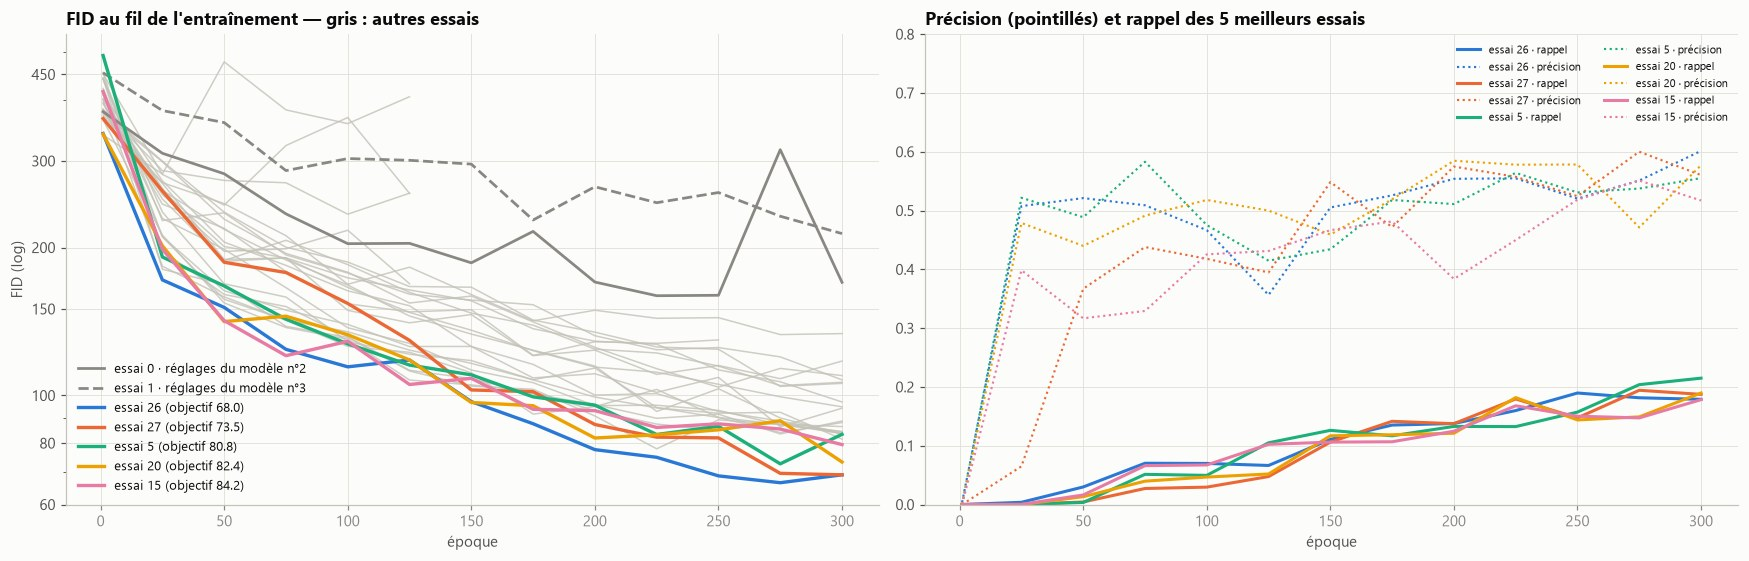

,essai,objectif,meilleur_FID,tendance,encore en progrès ?
26,26,68.0,66.5,0.3,plateau
27,27,73.5,69.0,-13.0,oui
5,5,80.8,72.6,-3.2,oui
20,20,82.4,73.2,-11.9,oui
15,15,84.2,79.4,-8.1,oui
9,9,85.5,83.5,-1.4,plateau
3,3,86.8,77.9,-5.4,oui
13,13,87.4,84.1,-2.1,plateau


In [6]:
curves = {}
for d in sorted(TRIALS_DIR.glob("trial_*")):
    if (d / "eval.csv").exists():
        curves[int(d.name.split("_")[1])] = pd.read_csv(d / "eval.csv")
top = comp.nsmallest(5, "objectif")["essai"].tolist()
refs = {0: "essai 0 · réglages du modèle n°2", 1: "essai 1 · réglages du modèle n°3"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
ax = axes[0]
for n, e in curves.items():
    if n not in top and n not in refs:
        ax.plot(e["epoch"], e["FID"], color=OTHER, lw=1, alpha=0.8)
for k, (n, lbl) in enumerate(refs.items()):
    ax.plot(curves[n]["epoch"], curves[n]["FID"], color=MUTED, lw=1.8, ls="--" if k else "-", label=lbl)
for k, n in enumerate(top):
    ax.plot(curves[n]["epoch"], curves[n]["FID"], color=CAT[k], lw=2.2, label=f"essai {n} (objectif {T.set_index('essai').loc[n, 'objectif']:.1f})")
ax.set_yscale("log"); ax.set_yticks([60, 80, 100, 150, 200, 300, 450]); ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
ax.yaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_xlabel("époque"); ax.set_ylabel("FID (log)"); ax.set_title("FID au fil de l'entraînement — gris : autres essais")
ax.legend(fontsize=8.5)

ax = axes[1]
for k, n in enumerate(top):
    e = curves[n]
    ax.plot(e["epoch"], e["recall"], color=CAT[k], lw=2, label=f"essai {n} · rappel")
    ax.plot(e["epoch"], e["precision"], color=CAT[k], lw=1.4, ls=":", label=f"essai {n} · précision")
ax.set_ylim(0, 0.8); ax.set_xlabel("époque"); ax.set_title("Précision (pointillés) et rappel des 5 meilleurs essais")
ax.legend(fontsize=7.5, ncol=2)
plt.tight_layout()
save(fig, "04_curves")
plt.show()

trend = comp.sort_values("objectif")[["essai", "objectif", "meilleur_FID", "tendance"]].head(8)
trend["encore en progrès ?"] = np.where(trend["tendance"] < -3, "oui", np.where(trend["tendance"] > 3, "rechute", "plateau"))
trend.round(1)

**Observations**

- **Aucun effondrement** parmi les bons essais : les courbes descendent régulièrement, sans les crises du modèle n°2
  (courbe grise pleine, essai 0, qui rechute brutalement à l'époque 275).
- **Les meilleurs essais progressaient encore à l'époque 300** : les essais 27, 20, 15, 5 gagnaient 3 à 13 points de
  FID sur les 50 dernières époques. Seul le n°26 semble avoir atteint un plateau. Votre remarque sur la convergence se
  vérifie : **300 époques ne suffisent pas**, et le classement pourrait changer avec un entraînement plus long — le
  n°27, en particulier, a une pente plus forte que le n°26.
- **Le rappel double** par rapport à nos modèles précédents (~0,19 contre 0,11 au mieux) et la précision atteint
  ~0,6 : les images sont à la fois plus réalistes et plus variées.

## 4. Les images : du modèle n°2 aux meilleurs réglages

Grille à bruit fixe de l'époque 300 de chaque essai (mêmes vecteurs latents pour tous). Les essais de l'étude ne
sauvegardent pas de checkpoint (pour économiser l'espace disque) : ces grilles sont la seule trace visuelle.

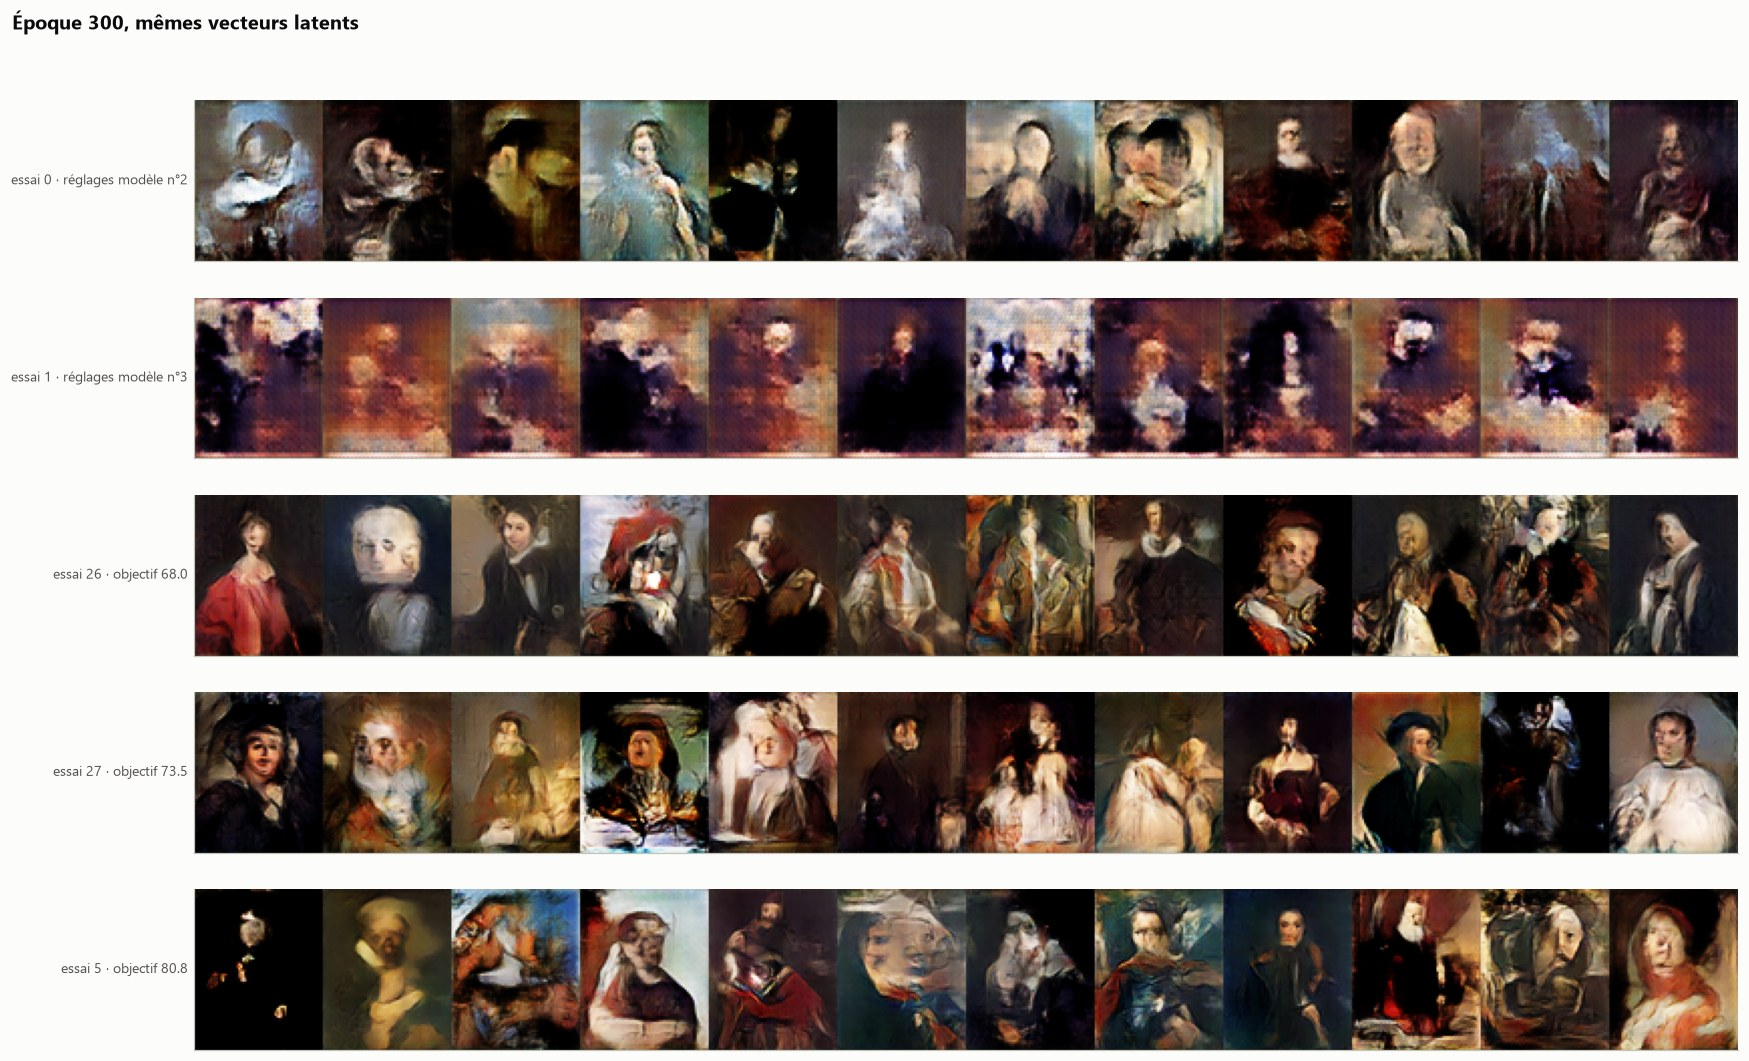

In [7]:
def tiles(path, n=12, w=64, h=80, ncol=8, p=2):
    g = np.asarray(Image.open(path).convert("RGB"))
    return np.concatenate([g[p + (i // ncol) * (h + p): p + (i // ncol) * (h + p) + h,
                             p + (i % ncol) * (w + p): p + (i % ncol) * (w + p) + w] for i in range(n)], axis=1)


show = [(0, "essai 0 · réglages modèle n°2"), (1, "essai 1 · réglages modèle n°3")] + \
       [(n, f"essai {n} · objectif {T.set_index('essai').loc[n, 'objectif']:.1f}") for n in top[:3]]
fig, axes = plt.subplots(len(show), 1, figsize=(16, 1.9 * len(show) + 0.4))
for ax, (n, lbl) in zip(axes, show):
    ax.imshow(tiles(TRIALS_DIR / f"trial_{n:03d}" / "samples" / "epoch_0300.png"))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_ylabel(lbl, rotation=0, ha="right", va="center", fontsize=9)
fig.suptitle("Époque 300, mêmes vecteurs latents", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.96))
save(fig, "05_samples")
plt.show()

**Observations** — le progrès est très net à l'œil. Avec les réglages du modèle n°3 (essai 1), ce ne sont que des
taches ; avec ceux du modèle n°2 (essai 0), des silhouettes floues. Les trois meilleurs essais produisent de **vrais
portraits** : buste, vêtements lisibles (col blanc, chapeau, robe rouge), fond cohérent, et pour la première fois
**des visages parfois reconnaissables** (yeux, nez, bouche, en particulier dans l'essai 26). Les visages restent
souvent déformés — à 64×80, ils ne font qu'une quinzaine de pixels.

## 5. Conclusion

| | Meilleur modèle avant Optuna (n°2) | Meilleur essai Optuna (n°26) |
|---|---|---|
| FID | 116 (meilleur point, puis effondrement) | **≈ 68** (moyenne des 3 dernières évaluations) |
| Précision / rappel | 0,51 / 0,11 | **0,60 / 0,18** |
| Stabilité | 2 effondrements | aucun |

Soit un **FID divisé par ~1,7**, en ne changeant **aucune ligne d'architecture** : uniquement des hyperparamètres. Le
modèle passe du niveau « bruit » (114) à proximité du niveau « flou léger » (61) de l'échelle de lecture.

**Trois enseignements pour la présentation :**
1. **L'équilibre G/D se règle par la quantité d'entraînement du discriminateur** (batch, `n_dis`, rapport des taux
   d'apprentissage), bien plus que par le choix de la perte ou même de la normalisation spectrale.
2. **β₁ = 0** fait partie des réglages décisifs, conformément à la littérature récente (SNGAN, BigGAN).
3. **Une technique n'a de valeur qu'avec ses hyperparamètres** : la normalisation spectrale, qui semblait un échec
   dans le notebook 06, fait partie du meilleur réglage.

**Limites de l'étude :**
- un seul entraînement par essai (même graine) : l'écart entre 68 et 73,5 est dans la marge de variabilité d'un GAN ;
- budget fixé en époques : les réglages à petit batch sont avantagés, car ils font plus de mises à jour ;
- 300 époques : les meilleurs essais n'avaient pas fini de converger.

**Étape suivante — confirmation.** Ré-entraîner les deux meilleurs réglages (n°26 et n°27) **plus longtemps (600
époques), avec 3 graines chacun**, en sauvegardant les checkpoints et avec l'évaluation complète. On saura ainsi si
l'amélioration est robuste, lequel est vraiment le meilleur, et on obtiendra le modèle final des portraits en 64×80
avant de passer au 128×160.